<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


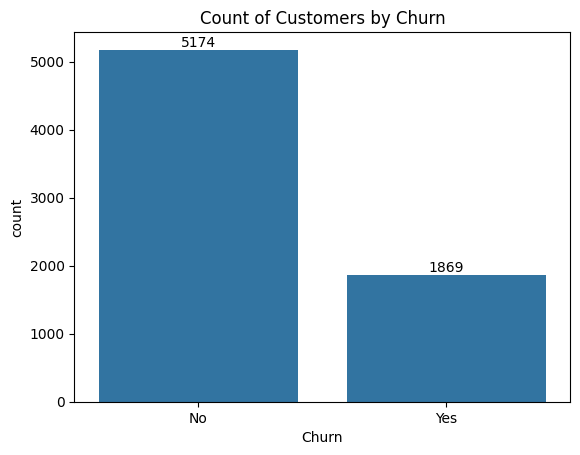

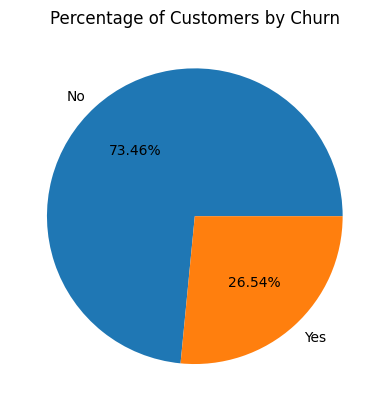

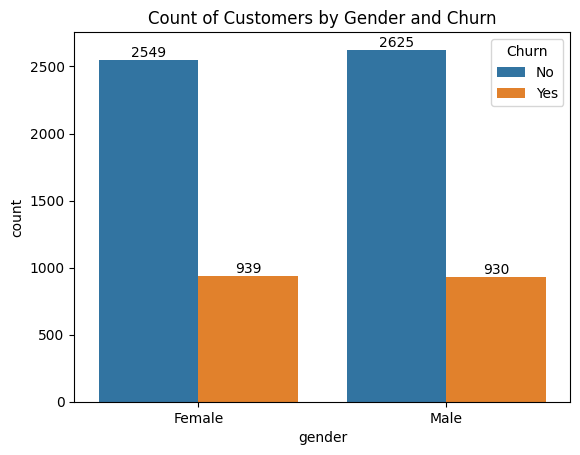

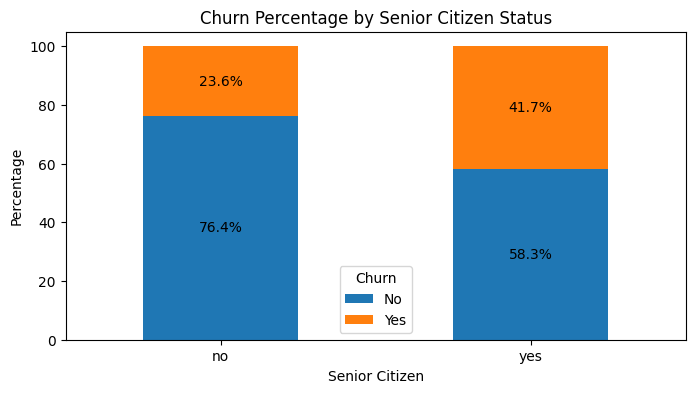

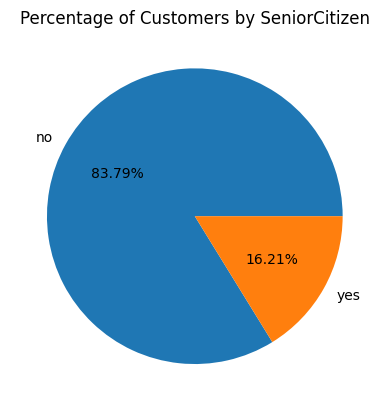

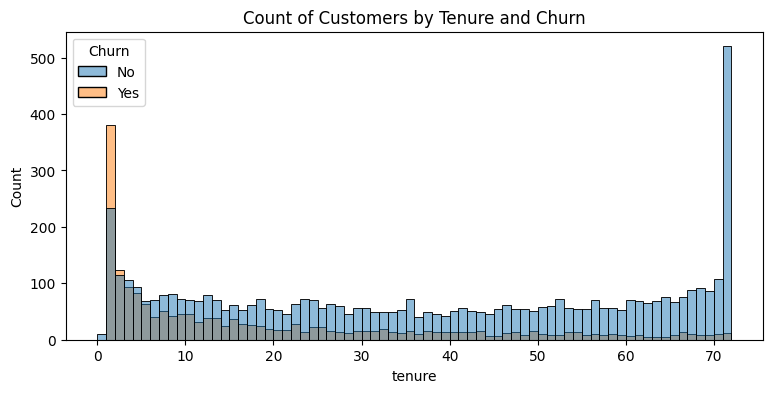

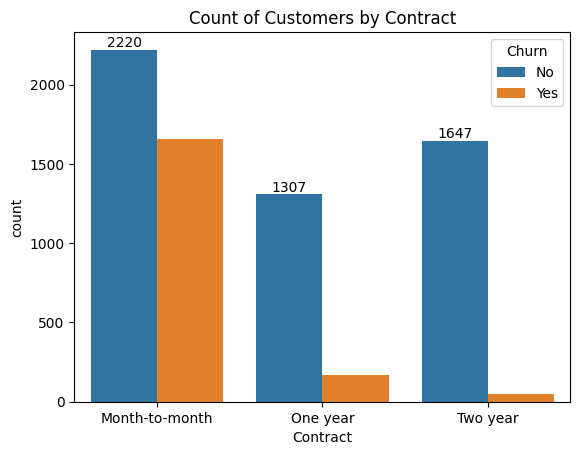

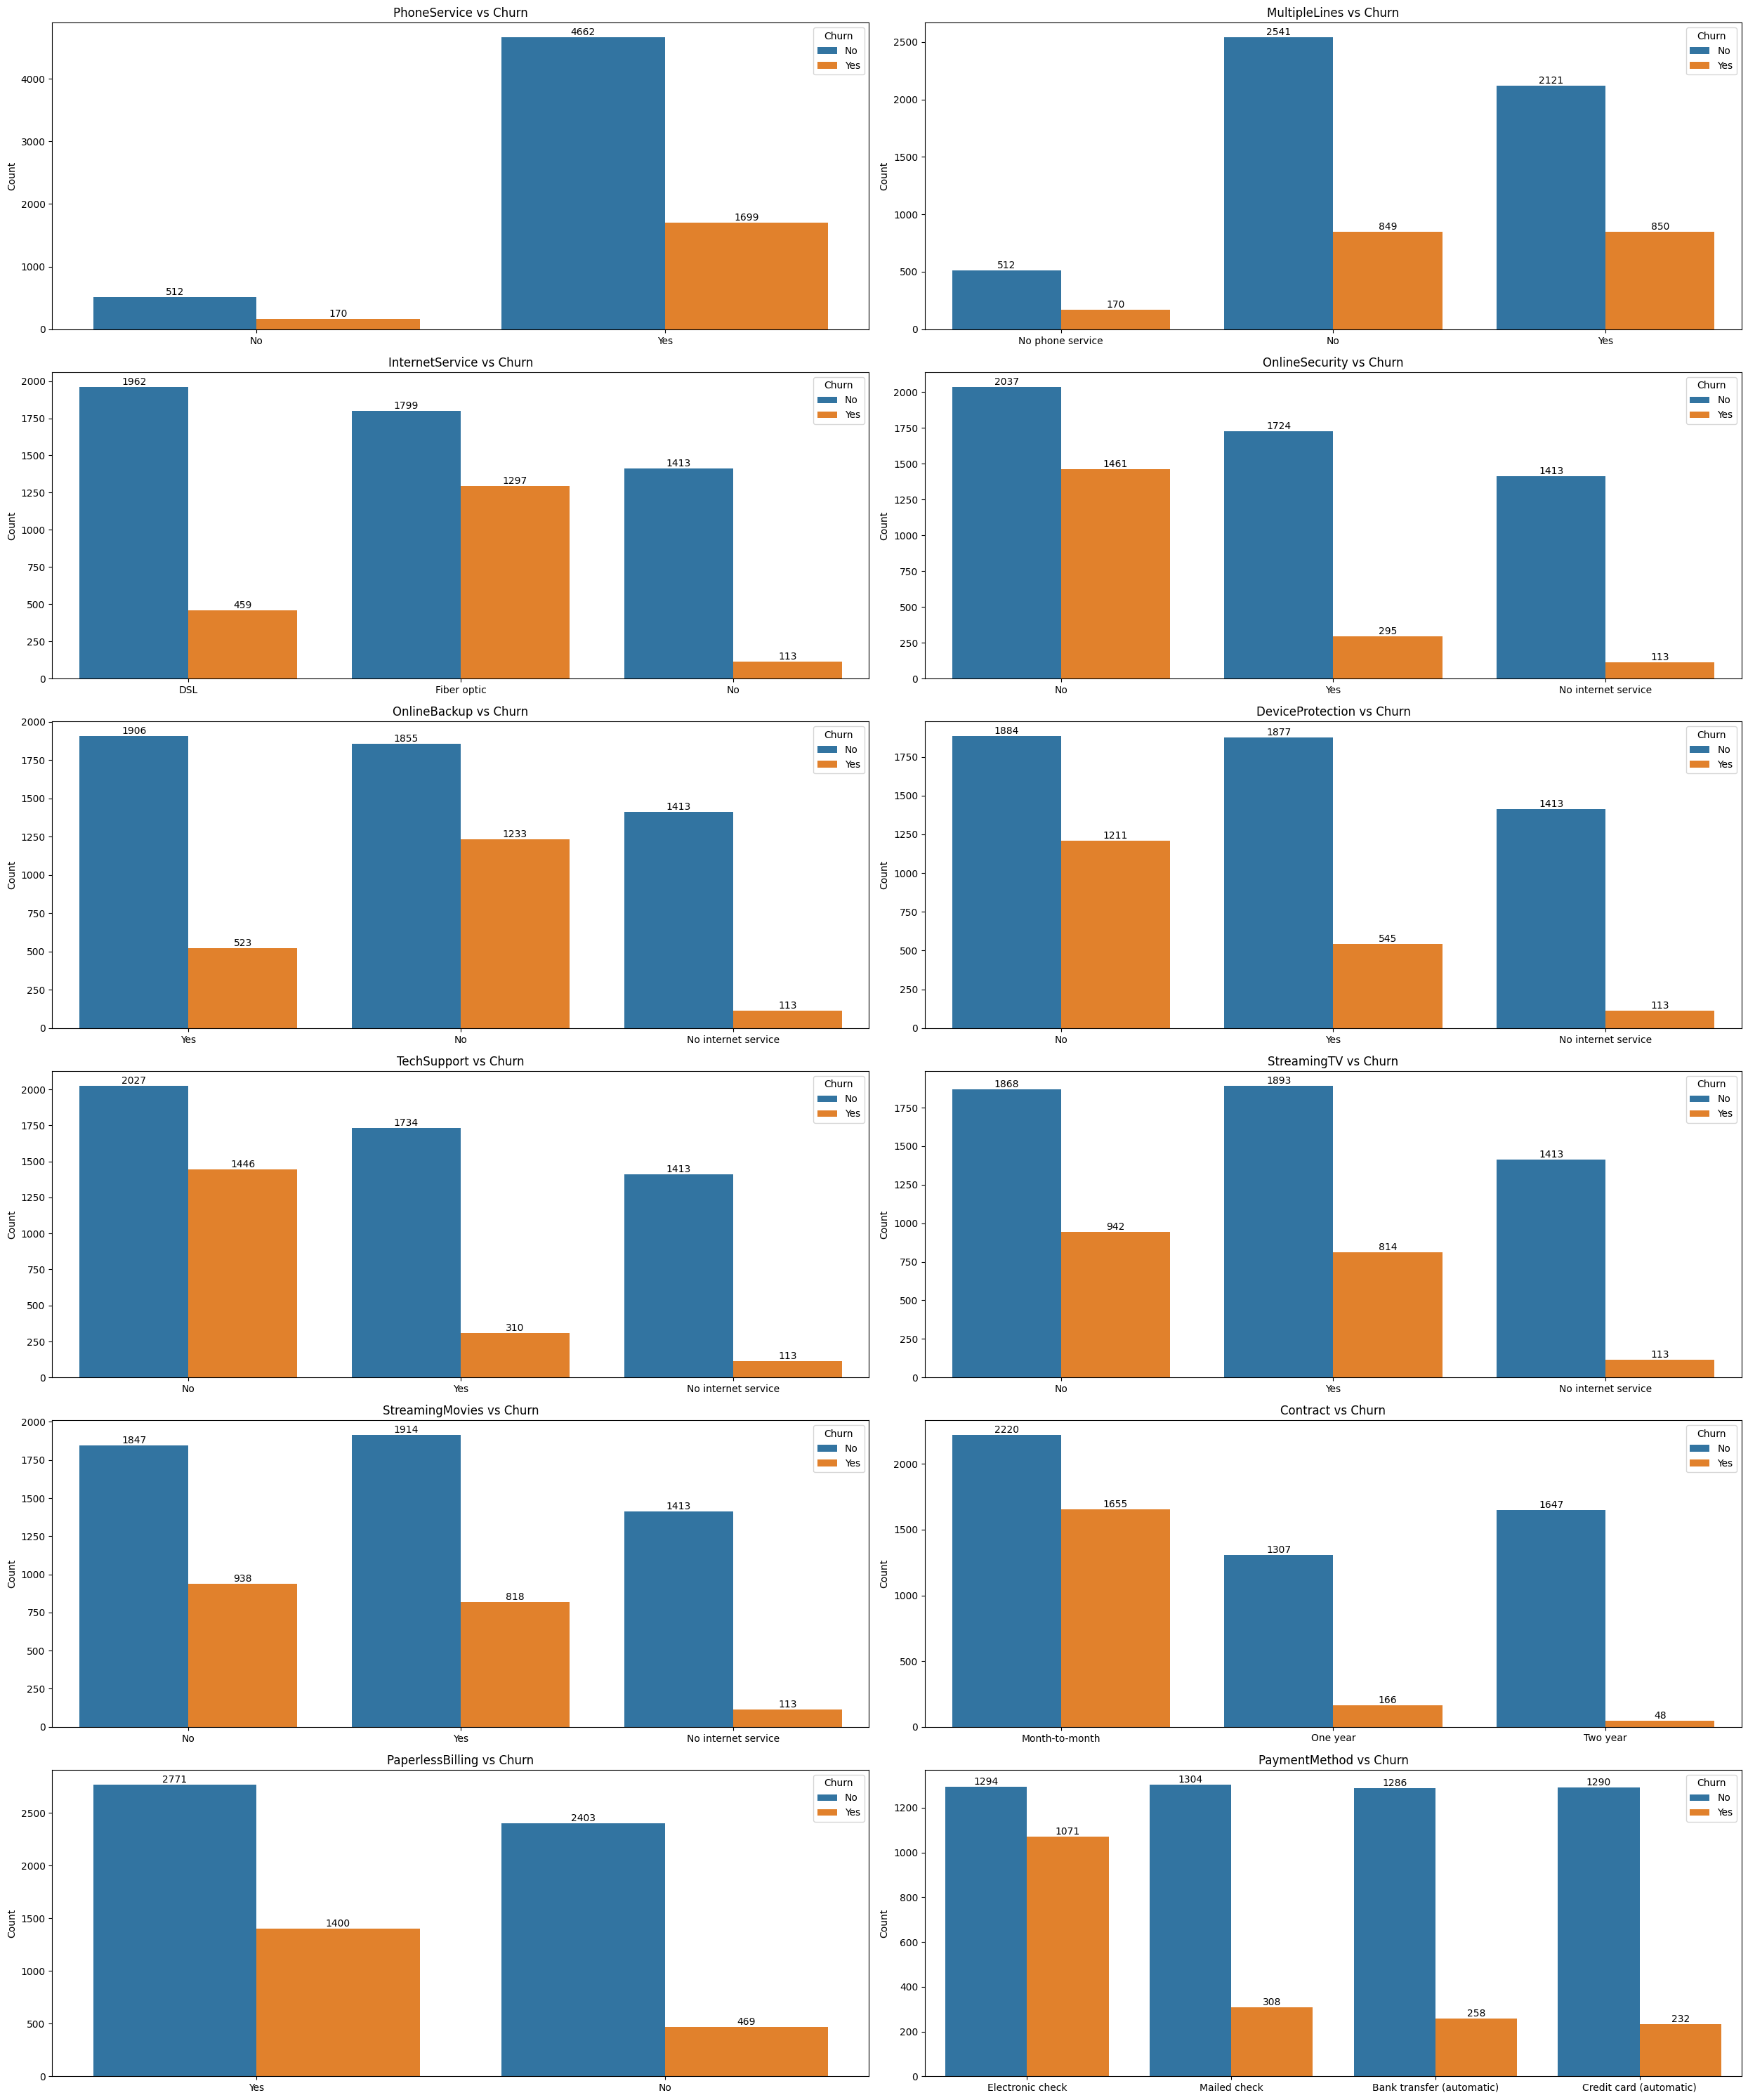

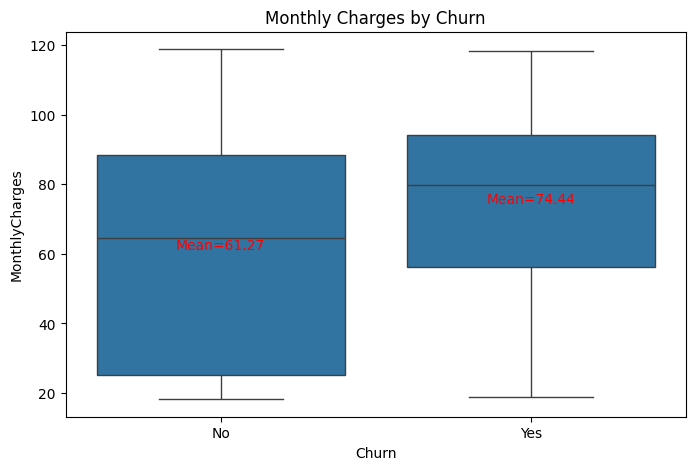

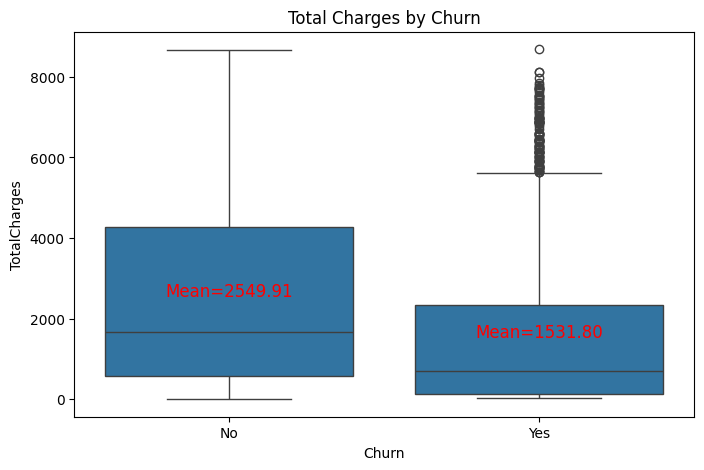

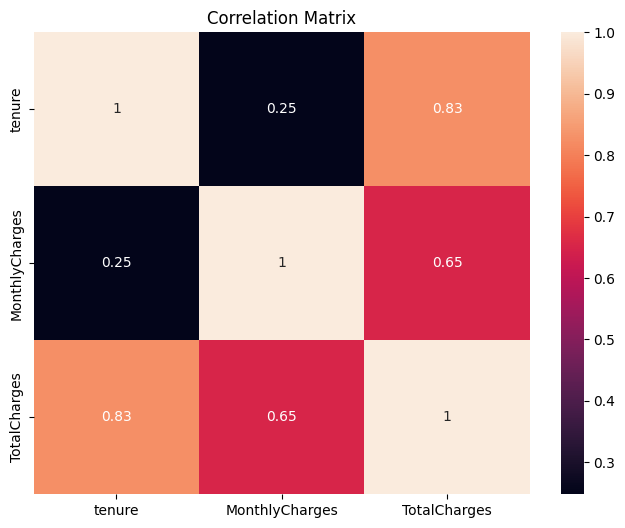

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
# ============================================================
# TELECOM CUSTOMER CHURN ANALYSIS (EDA)
# Author: Pratik
# Project Type: Exploratory Data Analysis (EDA)
# Tools Used: Python, Pandas, NumPy, Matplotlib, Seaborn
# Objective:
# Analyze customer churn behavior and identify key factors
# contributing to customer attrition.
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 2. LOAD DATASET
# ============================================================

df = pd.read_csv("Customer Churn.csv")

# Display first 10 records
df.head(10)

# Dataset dimensions (rows, columns)
df.shape

# Dataset information
df.info()


# ============================================================
# 3. DATA CLEANING
# ============================================================

# Replace blank values in TotalCharges with 0
df["TotalCharges"] = df["TotalCharges"].replace(" ", "0")

# Convert TotalCharges to float datatype
df["TotalCharges"] = df["TotalCharges"].astype(float)

# Check missing values
df.isnull().sum()

# Check duplicate rows
df.duplicated().sum()

# Check duplicate Customer IDs
df["customerID"].duplicated().sum()


# ============================================================
# 4. FEATURE TRANSFORMATION
# ============================================================

# Convert SeniorCitizen column
# 1 = yes
# 0 = no

def conv(value):
    if value == 1:
        return "yes"
    else:
        return "no"

df["SeniorCitizen"] = df["SeniorCitizen"].apply(conv)

# Convert datatype to string
df["SeniorCitizen"] = df["SeniorCitizen"].astype(str)

df.head()


# ============================================================
# 5. CHURN DISTRIBUTION ANALYSIS
# ============================================================

# Count of customers who churned vs retained

a = sns.countplot(x="Churn", data=df)

a.bar_label(a.containers[0])

plt.title("Count of Customers by Churn")

plt.savefig(
    "Count of Customers by Churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 6. CHURN PERCENTAGE ANALYSIS
# ============================================================

# Percentage share of churned and retained customers

gb = df.groupby("Churn").size()

plt.pie(
    gb,
    labels=gb.index,
    autopct="%1.2f%%"
)

plt.title("Percentage of Customers by Churn")

plt.savefig(
    "Percentage of Customers by Churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 7. GENDER VS CHURN ANALYSIS
# ============================================================

a = sns.countplot(
    x="gender",
    hue="Churn",
    data=df
)

a.bar_label(a.containers[0])
a.bar_label(a.containers[1])

plt.title("Count of Customers by Gender and Churn")

plt.savefig(
    "Count of Customers by Gender and Churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 8. SENIOR CITIZEN VS CHURN ANALYSIS
# ============================================================

# Percentage churn comparison for senior and non-senior customers

pct = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

ax = pct.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 4)
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        label_type="center"
    )

plt.title("Churn Percentage by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Percentage")
plt.legend(title="Churn")
plt.xticks(rotation=0)

plt.savefig(
    "Churn Percentage by Senior Citizen Status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 9. SENIOR CITIZEN DISTRIBUTION
# ============================================================

gb = df.groupby("SeniorCitizen").size()

plt.pie(
    gb,
    labels=gb.index,
    autopct="%1.2f%%"
)

plt.title("Percentage of Customers by SeniorCitizen")

plt.savefig(
    "Percentage of Customers by SeniorCitizen.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 10. TENURE VS CHURN ANALYSIS
# ============================================================

plt.figure(figsize=(9, 4))

sns.histplot(
    x="tenure",
    hue="Churn",
    data=df,
    bins=72
)

plt.title("Count of Customers by Tenure and Churn")

plt.savefig(
    "Count of Customers by Tenure and Churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 11. CONTRACT TYPE VS CHURN ANALYSIS
# ============================================================

a = sns.countplot(
    x="Contract",
    data=df,
    hue="Churn"
)

a.bar_label(a.containers[0])

plt.title("Count of Customers by Contract")

plt.savefig(
    "Count of Customers by contract.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 12. SERVICE USAGE VS CHURN DASHBOARD
# ============================================================

service_cols = [
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod'
]

rows = 6
cols = 2

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(25, 30)
)

axes = axes.flatten()

for i, col in enumerate(service_cols):

    ax = sns.countplot(
        x=col,
        hue="Churn",
        data=df,
        ax=axes[i]
    )

    for container in ax.containers:
        ax.bar_label(container)

    ax.set_title(f"{col} vs Churn")
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=0)

for j in range(len(service_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.savefig(
    "service_vs_churn_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 13. MONTHLY CHARGES VS CHURN
# ============================================================

plt.figure(figsize=(8, 5))

ax = sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

means = df.groupby("Churn")["MonthlyCharges"].mean()

for i, value in enumerate(means):
    plt.text(
        i,
        value,
        f"Mean={value:.2f}",
        ha="center",
        color="red"
    )

plt.title("Monthly Charges by Churn")

plt.savefig(
    "Monthly Charges by Churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 14. TOTAL CHARGES VS CHURN
# ============================================================

plt.figure(figsize=(8, 5))

ax = sns.boxplot(
    x="Churn",
    y="TotalCharges",
    data=df
)

means = df.groupby("Churn")["TotalCharges"].mean()

for i, value in enumerate(means):
    plt.text(
        i,
        value,
        f"Mean={value:.2f}",
        ha="center",
        color="red",
        fontsize=12
    )

plt.title("Total Charges by Churn")

plt.savefig(
    "Total Charges by Churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 15. CORRELATION ANALYSIS
# ============================================================

corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="rocket"
)

plt.title("Correlation Matrix")

plt.savefig(
    "Correlation Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 16. DOWNLOAD GENERATED FILES
# ============================================================

from google.colab import files

files.download("service_vs_churn_dashboard.png")
files.download("Count of Customers by contract.png")
files.download("Count of Customers by Tenure and Churn.png")
files.download("Percentage of Customers by SeniorCitizen.png")
files.download("Count of Customers by Gender and Churn.png")
files.download("Percentage of Customers by Churn.png")
files.download("Count of Customers by Churn.png")
files.download("Monthly Charges by Churn.png")
files.download("Total Charges by Churn.png")
files.download("Correlation Matrix.png")

In [2]:
# Save cleaned dataset
df.to_csv(
    "Telecom_Customer_Churn_Cleaned.csv",
    index=False
)

files.download(
    "Telecom_Customer_Churn_Cleaned.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>